# Phase 2 — Autograd: How a Model Knows Which Way to Improve

Phase 1 ended stuck. We could measure **how wrong** a prediction was, but had no idea
**which way to move** to make it better. This notebook removes that wall, and it is the most
important idea in the whole framework.

### The problem, as a picture

Imagine standing on a hillside in thick fog. Somewhere below is the bottom of the valley —
the settings that make your model as accurate as possible. You can't see it. You can't see
anything.

But you *can* feel the ground under your feet. You can tell which direction slopes downhill,
and how steeply.

So you take a small step that way. Then feel again. Then step again. Do that enough times
and you reach the bottom without ever having seen it.

**That's training a neural network.** Really — that's it.

- The **hill's height** at your position = the **loss** (how wrong you currently are)
- The **slope under your feet** = the **gradient**
- The **size of each step** = the **learning rate**
- Walking downhill over and over = **gradient descent**

### So what does autograd actually do?

The gradient is the hard part. It means answering, for every single parameter: *"if I nudge
this one up slightly, does the total error go up or down, and by how much?"*

That's calculus — derivatives and the chain rule. Doable by hand for two parameters. A real
network has millions, and they're all tangled together.

**Autograd does it for you, exactly and automatically.** Here's the trick:

> While you do the maths forward, PyTorch quietly writes down every operation you performed —
> like keeping a receipt for each step. When you call `.backward()`, it reads that receipt in
> reverse and applies the chain rule at every step, working out each parameter's share of the
> blame.

You write the forward maths as normal code. PyTorch handles the backward direction. That
division of labour is the entire reason the framework exists.

### The vocabulary

| Term | What it actually means |
|---|---|
| `requires_grad=True` | "Start recording what I do to this tensor" |
| computation graph | The receipt — the record of which operations led to which values |
| `grad_fn` | "This value came out of a multiplication" (or add, or whatever) |
| leaf tensor | One **you** made, as opposed to one that fell out of a calculation |
| `.backward()` | "Read the receipt backwards and work out everyone's blame" |
| `.grad` | The answer: which way to move this parameter, and how urgently |
| `torch.no_grad()` | "Stop recording for a moment — this bit isn't part of the model" |

## What this notebook covers
```
turning on recording -> backward(), checked by hand -> updating weights safely
    -> why gradients must be reset -> a complete training loop
    -> switching recording off -> the shortcuts Phase 3 replaces this with
```

## Section 1 — Turning On the Recording

`requires_grad=True` means *"start keeping a receipt for this tensor."* From that moment,
every operation involving it gets written down.

Notice which tensors get it and which don't, because the rule is consistent throughout
PyTorch:

- **`w` (a parameter the model must learn)** → `requires_grad=True`. We need to know how to
  improve it.
- **`x` (input data)** → nothing. The data is what it is; we're not going to "improve" your
  photos.

The recording spreads on its own. Multiply a tracked tensor by an untracked one and the
result is tracked, because it now depends on something we care about.

### Leaf vs non-leaf

A **leaf** is a tensor you created directly. A **non-leaf** is one that came out of a
calculation.

It matters because **gradients only get stored on leaves.** Those are your parameters — the
things you can actually change. Intermediate values are just stops along the way; PyTorch
computes through them but doesn't keep their gradients, since there'd be no use for them.

In [1]:
import torch

torch.manual_seed(42)

# requires_grad=True means: "keep a receipt of everything done to this tensor,
# so I can ask later how to improve it."
#
# Rule of thumb for which tensors get it:
#   parameters the model must LEARN  -> requires_grad=True
#   input data                       -> leave it off (we don't improve the data)
w = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(4.0)   # just an input. Nothing to learn here, so no receipt needed.

y = w * x

print(f'w = {w}')
print(f'x = {x}')
print(f'y = w * x = {y}')
print(f'y.grad_fn        : {y.grad_fn}         <- remembers the op that created y (multiplication)')
print(f'y.requires_grad  : {y.requires_grad}   <- True, inherited from w')

print(f'\nw.is_leaf : {w.is_leaf}   <- created directly by us, not from an operation')
print(f'y.is_leaf : {y.is_leaf}  <- created FROM an operation, so it is NOT a leaf')
print(f'w.grad    : {w.grad}      <- None until we call .backward()')

w = 3.0
x = 4.0
y = w * x = 12.0
y.grad_fn        : <MulBackward0 object at 0x11576feb0>         <- remembers the op that created y (multiplication)
y.requires_grad  : True   <- True, inherited from w

w.is_leaf : True   <- created directly by us, not from an operation
y.is_leaf : False  <- created FROM an operation, so it is NOT a leaf
w.grad    : None      <- None until we call .backward()


Here's the receipt PyTorch is keeping:

```
w (leaf, requires_grad=True) ──┐
                                ├─► MulBackward0 ──► y
x (no grad)         ───────────┘
```

Read it as: *"y was produced by multiplying, and one of the things multiplied was w, which
someone wants gradients for."*

`y.backward()` walks that arrow **backwards** and works out how much `y` would change if `w`
changed slightly. The answer lands in `w.grad`.

### Let's check autograd's homework

The cell below computes a gradient two ways: once with `.backward()`, and once with the
chain rule worked out by hand. They should match exactly.

Doing this once is worth the effort — after that you can trust autograd forever and never
think about it again.

Our tiny model is `y_pred = w * x`, and the error is `loss = (y_pred - y_true)²`. Applying
the chain rule:

```
loss = (w*x - y_true)²

d(loss)/dw = 2 * (w*x - y_true) * x
             ↑            ↑        ↑
     outer square    the error   inner derivative
      differentiated             of (w*x) w.r.t. w
```

With `w=2`, `x=3`, `y_true=10`: the prediction is 6, so the error is −4, and the gradient is
`2 × (−4) × 3 = −24`.

**A negative gradient means "increasing w reduces the error"** — so `w` should go up. Which
makes sense: we predicted 6 and needed 10.

In [2]:
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)
y_true = torch.tensor(10.0)

# ── FORWARD PASS — MAKE A PREDICTION AND SEE HOW WRONG IT IS ─────────────────
# w=2 and x=3, so we predict 6. The right answer is 10, so we're off by 4.
y_pred = w * x
loss = (y_pred - y_true) ** 2   # squared error: (6 - 10)^2 = 16

print(f'y_pred = {y_pred}')
print(f'loss   = {loss}')
print(f'loss.grad_fn : {loss.grad_fn}')

# ── BACKWARD PASS — WORK OUT WHICH WAY TO MOVE w ─────────────────────────────
# One call reads the receipt backwards and fills in w.grad.
# The result is NEGATIVE, which means 'increasing w would reduce the error' --
# correct, since we predicted 6 and needed 10.
loss.backward()
print(f'\nw.grad (from autograd)    : {w.grad}')

# ── CHECKING AUTOGRAD'S HOMEWORK ─────────────────────────────────────────────
# The same derivative, worked out by hand with the chain rule:
#
#   loss       = (w*x - y_true)^2
#   d(loss)/dw = 2 * (w*x - y_true) * x
#                 ^        ^          ^
#          the square   the error   derivative of (w*x)
#          differentiated           with respect to w
#
# = 2 * (6 - 10) * 3 = -24. Worth doing once; then you can trust it forever.
manual_grad = 2 * (w.item() * x.item() - y_true.item()) * x.item()
print(f'w.grad (manual chain rule): {manual_grad}')

y_pred = 6.0
loss   = 16.0
loss.grad_fn : <PowBackward0 object at 0x11594eb90>

w.grad (from autograd)    : -24.0
w.grad (manual chain rule): -24.0


## Section 2 — Updating a Weight Without Breaking Everything

We have the gradient. Now use it. The rule of gradient descent is one line:

```
new_weight = old_weight − learning_rate × gradient
```

The **minus** is the whole trick. The gradient points *uphill* — toward more error — so we
step the opposite way, downhill.

Check it against our numbers: the gradient was −24, so we subtract `0.1 × (−24)` = we **add**
2.4 to `w`. `w` goes up, exactly as it should.

**Learning rate** is just the step size, and it's the setting you'll fiddle with most:

- **Too big** → you leap over the valley floor and bounce around, or shoot off to infinity.
  (Loss becoming `nan` is usually this.)
- **Too small** → you creep downhill and training takes forever.
- Typical starting points: `0.1` for simple problems, `0.001` for Adam on real networks.

### Why `torch.no_grad()` is wrapped around the update

Here's the subtle bit. `w` is being recorded. If we just wrote `w -= lr * w.grad`, PyTorch
would dutifully write *that subtraction* onto the receipt too — as though adjusting the
weight were part of the model's maths.

It isn't. It's **bookkeeping**: us tidying up between attempts. Recording it would corrupt
the history and PyTorch stops you with a `RuntimeError`.

`torch.no_grad()` says *"stop recording for these few lines."* The weight changes, and the
receipt stays clean.

In [5]:
x = torch.tensor(3.0)
w = torch.tensor(2.0, requires_grad=True)   # the number we're trying to learn
y_true = torch.tensor(10.0)                 # the correct answer
learning_rate = 0.1                         # how big a step to take downhill.
                                            # too big -> overshoot; too small -> forever

# STEP 1: forward pass -- make a prediction with the weight we currently have
y_pred = w * x

# STEP 2: measure how wrong that prediction was
loss = (y_pred - y_true) ** 2

# STEP 3: work out w's share of the blame, and which way it should move
loss.backward()

print('Before update')
print(f'  weight : {w.item():.4f}')
print(f'  w.grad : {w.grad.item():.4f}')

# STEP 4: take the step downhill.
#
# The MINUS is the key: the gradient points UPHILL toward more error, so we go
# the other way. Here the gradient is negative, so subtracting it makes w bigger.
#
# Why no_grad(): adjusting the weight is US doing bookkeeping between attempts,
# not part of the model's maths. Recording it would corrupt the receipt, and
# PyTorch stops you with a RuntimeError if you try.
with torch.no_grad():
    w -= learning_rate * w.grad

# STEP 5: clear the tally. Gradients ADD UP rather than replace, so skipping
# this makes the next step wrong. See the next section.
w.grad.zero_()

print('\nAfter update')
print(f'  weight : {w.item():.4f}')

Before update
  weight : 2.0000
  w.grad : -24.0000

After update
  weight : 4.4000


## Section 3 — Why You Must Reset the Gradient Every Time

This one catches everybody at least once, and it fails **silently** — no error, just a model
that trains badly for no visible reason.

**PyTorch adds to `.grad`. It does not replace it.**

Call `.backward()` twice without clearing in between and you don't get the second gradient —
you get the first *plus* the second. Do it across a training loop and by epoch 50 you're
carrying a nonsensical pile-up of every gradient you ever computed. Your steps get wildly too
big and training falls apart.

### Why on earth would it work that way?

It's deliberate, and occasionally very useful. Sometimes you want to process a large batch in
several smaller pieces because it won't fit in memory all at once. Running `.backward()` on
each piece and letting the gradients pile up gives exactly the same answer as one big batch —
that's called *gradient accumulation*, and it only works because of this behaviour.

The cost is that everyone else must remember to clear up. **Every training loop needs
`.grad.zero_()` (or `optimizer.zero_grad()`) before each `backward()`.** It's the single most
commonly forgotten line in PyTorch.

In [6]:
w = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(2.0)

# --- First backward pass: w.grad goes from None to 2.0 ---
y1 = w * x
y1.backward()
print(f'After 1st backward: w.grad = {w.grad}')   # d(y1)/dw = x = 2.0

# --- Second backward pass, WITHOUT clearing first ---
# The same calculation, so you'd expect 2.0 again. Watch what actually happens:
y2 = w * x
y2.backward()
print(f'After 2nd backward (no zeroing): w.grad = {w.grad}   <- ACCUMULATED (2.0 + 2.0), not overwritten!')

# --- The fix: clear the tally first ---
# One line, and it's the most commonly forgotten line in all of PyTorch.
# It fails silently -- no error, just a model that trains badly.
w.grad.zero_()
y3 = w * x
y3.backward()
print(f'After zero_() + 3rd backward: w.grad = {w.grad}   <- correct again')

After 1st backward: w.grad = 2.0
After 2nd backward (no zeroing): w.grad = 4.0   <- ACCUMULATED (2.0 + 2.0), not overwritten!
After zero_() + 3rd backward: w.grad = 2.0   <- correct again


## Section 4 — A Complete Training Loop

Everything so far, assembled. Five steps, repeated:

```
1. FORWARD    y_pred = w * x               make a prediction
2. LOSS       how wrong was it?
3. BACKWARD   loss.backward()              work out each parameter's blame
4. UPDATE     w -= lr * w.grad             step downhill (inside no_grad)
5. RESET      w.grad.zero_()               clear the tally for next time
```

**Learn this shape.** Every PyTorch training loop you ever write — an MLP, a CNN, a
transformer with a billion parameters — is these same five steps. Only the model and the data
get bigger.

An **epoch** means one full pass over your training data. Ten epochs means the model has seen
everything ten times.

We're starting `w` at 0.0 when the right answer is 2.0. Watch the loss fall and `w` climb
toward 2 — this is the walk downhill, printed one step at a time.

Epoch  1: w = 3.0000  loss = 30.0000
Epoch  2: w = 1.5000  loss = 7.5000
Epoch  3: w = 2.2500  loss = 1.8750
Epoch  4: w = 1.8750  loss = 0.4688
Epoch  5: w = 2.0625  loss = 0.1172
Epoch  6: w = 1.9688  loss = 0.0293
Epoch  7: w = 2.0156  loss = 0.0073
Epoch  8: w = 1.9922  loss = 0.0018
Epoch  9: w = 2.0039  loss = 0.0005
Epoch 10: w = 1.9980  loss = 0.0001

True w should converge toward 2.0. Learned w = 1.9980


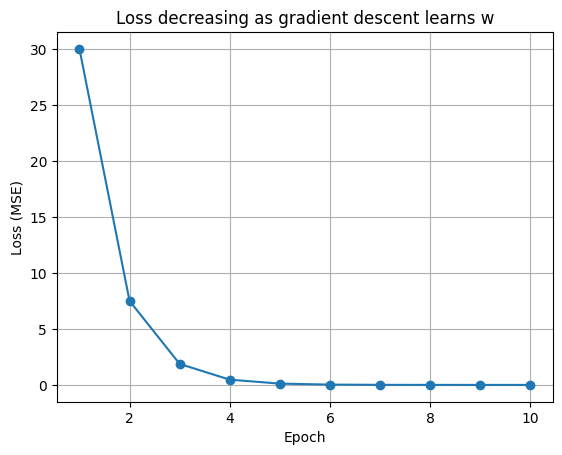

In [7]:
import matplotlib.pyplot as plt

# The task: find w so that w * x matches y. The right answer is w = 2,
# but we're starting from 0 and have to walk there one step at a time.
x = torch.tensor([1.0, 2.0, 3.0, 4.0])
y_true = torch.tensor([2.0, 4.0, 6.0, 8.0])

w = torch.tensor(0.0, requires_grad=True)   # a deliberately wrong starting point
lr = 0.1
epochs = 10
loss_history = []

for epoch in range(epochs):
    # STEP 1 -- forward: predict with the weight we have right now
    y_pred = w * x
    loss = ((y_pred - y_true) ** 2).mean()

    # STEP 3 -- backward: fill in w.grad with which way to move and how urgently
    loss.backward()

    # STEP 4 -- step downhill. Wrapped in no_grad because this is bookkeeping,
    # not part of the model's maths.
    with torch.no_grad():
        w -= lr * w.grad

    # STEP 5 -- clear the tally, or next epoch's gradient gets added to this one's
    w.grad.zero_()

    loss_history.append(loss.item())
    print(f'Epoch {epoch+1:2d}: w = {w.item():.4f}  loss = {loss.item():.4f}')

print(f'\nTrue w should converge toward 2.0. Learned w = {w.item():.4f}')

plt.plot(range(1, epochs + 1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss decreasing as gradient descent learns w')
plt.grid(True)
plt.show()

## Section 5 — Switching the Recording Off

Recording costs memory and time. During training that's a price worth paying, because you
need the gradients. Once you're just *using* the model, it's pure waste.

Two ways to opt out:

### `torch.no_grad()` — for a whole block

```python
with torch.no_grad():
    predictions = model(test_data)
```

Nothing inside gets recorded. **Always use this when evaluating or predicting.** It's faster,
uses noticeably less memory, and on a big model it's the difference between fitting in memory
and not.

### `.detach()` — for one tensor

Hands back the same numbers with the history snipped off. Use it when you want a *value*
without dragging its entire past along — collecting losses for a chart, for instance.

### The error this explains

Try calling `.numpy()` on a tensor that's still being recorded and PyTorch refuses. NumPy has
no concept of gradients, so silently dropping the history would be a trap.

The fix is to say what you mean: `y.detach().numpy()`. You'll hit this constantly when
plotting, and now you know why.

In [8]:
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(5.0)

y = w * x
print(f'y.requires_grad : {y.requires_grad}')

# ── AN ERROR YOU WILL DEFINITELY HIT ─────────────────────────────────────────
# NumPy knows nothing about gradients, so PyTorch refuses to hand over a tensor
# that's still being recorded rather than silently dropping the history.
# You'll meet this the first time you try to plot something.
try:
    y.numpy()
except RuntimeError as e:
    print(f'\ny.numpy() fails while requires_grad=True:\n  RuntimeError: {e}')

# ── .detach() — TAKE THE NUMBERS, LEAVE THE HISTORY ──────────────────────────
# Same values, receipt snipped off. y.detach().numpy() is the fix for the error
# above, and it's what you'll write every time you plot a loss curve.
y_detached = y.detach()
print(f'\ny_detached.requires_grad : {y_detached.requires_grad}   <- graph link removed')
print(f'y_detached.numpy() works  : {y_detached.numpy()}')
print(f'shares data with y        : {y_detached.data_ptr() == y.data_ptr()}')

# ── torch.no_grad() — STOP RECORDING FOR A WHOLE BLOCK ───────────────────────
# Use this whenever you're just USING the model rather than training it.
# Faster, and it saves a lot of memory on a big model.
print('\n=== Inside torch.no_grad() ===')
with torch.no_grad():
    prediction = w * x
    print(f'prediction.requires_grad : {prediction.requires_grad}   <- never tracked, saves memory/compute')

# The standard shape of any prediction function you'll write from here on:
def predict(w, x):
    with torch.no_grad():
        return w * x

print(f'\npredict(w, x) = {predict(w, x).item()}')

y.requires_grad : True

y.numpy() fails while requires_grad=True:
  RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

y_detached.requires_grad : False   <- graph link removed
y_detached.numpy() works  : 10.0
shares data with y        : True

=== Inside torch.no_grad() ===
prediction.requires_grad : False   <- never tracked, saves memory/compute

predict(w, x) = 10.0


## Section 6 — The Shortcuts You'll Actually Use

Everything so far was done by hand so you could watch the machinery work. Nobody writes it
that way in practice.

Below is the **exact same training loop**, using PyTorch's built-in pieces. Compare them line
by line:

| Doing it by hand | The built-in version | What it does |
|---|---|---|
| `w = torch.tensor(0.0, requires_grad=True)` | `nn.Linear(1, 1)` | Holds the parameters |
| `y_pred = w * x` | `model(x)` | Forward pass |
| `((y_pred - y_true) ** 2).mean()` | `nn.MSELoss()` | Measures the error |
| `with torch.no_grad(): w -= lr * w.grad` | `optimizer.step()` | Takes the downhill step |
| `w.grad.zero_()` | `optimizer.zero_grad()` | Clears the tally |

Same maths, same result. The difference is that the built-in version scales: `optimizer.step()`
updates *every* parameter in a million-parameter network with one call, and `nn.Linear` keeps
track of them all for you.

**This is why doing it manually first was worth it.** When you write `optimizer.step()` in
Phase 3, you'll know it's `w -= lr * w.grad` underneath — not magic, just the same subtraction
applied a million times.

In [9]:
import torch.nn as nn

# The exact same problem as Section 4 (learn y = 2x), but written the way you'll
# actually write it from now on. Compare each line against the manual version.
# Note the extra brackets: nn.Linear wants 2D input, shaped (batch, features).
# Four samples, one feature each -> (4, 1). This shape rule catches everyone once.
x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_true = torch.tensor([[2.0], [4.0], [6.0], [8.0]])

# Same three jobs as the manual version -- something to hold the weight, a rule
# for updating it, and a way to score the error -- just packaged up so they
# scale to millions of parameters instead of one.
model = nn.Linear(in_features=1, out_features=1, bias=False)   # holds w for us
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)         # does the downhill step
criterion = nn.MSELoss()                                        # measures the error

for epoch in range(epochs):
    y_pred = model(x)                # STEP 1: forward (calls the model like a function)
    loss = criterion(y_pred, y_true)

    optimizer.zero_grad()            # STEP 5: clear the tally (done first here, same effect)
    loss.backward()                  # STEP 3: work out the blame -- identical to before
    optimizer.step()                 # STEP 4: step downhill, for EVERY parameter at once

    print(f'Epoch {epoch+1:2d}: w = {model.weight.item():.4f}  loss = {loss.item():.4f}')

print('\nSame result as the manual loop, learned via nn.Linear + optim.SGD.')
print('This is exactly what Phase 3 (torch.nn) builds on.')

Epoch  1: w = 2.6177  loss = 11.4477
Epoch  2: w = 1.6911  loss = 2.8619
Epoch  3: w = 2.1544  loss = 0.7155
Epoch  4: w = 1.9228  loss = 0.1789
Epoch  5: w = 2.0386  loss = 0.0447
Epoch  6: w = 1.9807  loss = 0.0112
Epoch  7: w = 2.0097  loss = 0.0028
Epoch  8: w = 1.9952  loss = 0.0007
Epoch  9: w = 2.0024  loss = 0.0002
Epoch 10: w = 1.9988  loss = 0.0000

Same result as the manual loop, learned via nn.Linear + optim.SGD.
This is exactly what Phase 3 (torch.nn) builds on.


## Phase 2 Summary

### Cheat sheet
```
Recording:
  requires_grad=True      -> start keeping a receipt for this tensor
  tensor.grad_fn           -> which operation produced this value
  tensor.is_leaf            -> True if you made it, False if it came from a calculation
  loss.backward()           -> read the receipt backwards, fill in every .grad
  tensor.grad                -> the answer (None until backward() has run)

Updating a parameter:
  with torch.no_grad():
      w -= lr * w.grad         <- the update is bookkeeping, so don't record it
  w.grad.zero_()               <- REQUIRED: gradients ADD UP, they don't replace

Switching recording off:
  tensor.detach()                -> same numbers, history snipped off
  with torch.no_grad(): ...       -> stop recording for a whole block (use when evaluating)

The five-step loop (memorise this shape):
  1. y_pred = model(x)          forward
  2. loss = criterion(...)      how wrong?
  3. loss.backward()            who's to blame?
  4. optimizer.step()           step downhill
  5. optimizer.zero_grad()      clear the tally

The three errors you will actually hit:
  - Forgot .zero_()          -> no error at all, just gradients quietly piling up
                                and training falling apart. Check this FIRST.
  - Updated a weight outside no_grad()  -> RuntimeError about a leaf variable
  - Called .numpy() on a recorded tensor -> RuntimeError; use .detach().numpy()
```

### The four things worth memorising

1. **Training is walking downhill in fog.** Loss is your height, the gradient is the slope,
   the learning rate is your stride.
2. **A negative gradient means increase the parameter.** That's why the update subtracts.
3. **Gradients accumulate.** Forgetting to zero them is the most common bug in PyTorch and it
   produces no error message.
4. **`no_grad()` when you're not training.** Faster, and much lighter on memory.

### Test yourself before moving on

1. `w = 3.0`, `x = 2.0`, `loss = (w*x - 10)²`. Work out `w.grad` by hand, then check it with
   autograd.
2. Delete the `w.grad.zero_()` line from the Section 4 loop. Predict what happens to the loss
   before you run it.
3. Why does the update need `torch.no_grad()`? What does PyTorch do if you leave it out?
4. Set the learning rate to `1.5` in Section 4 and explain the result.

### Up next — Phase 3: `torch.nn`
Real models with `nn.Module`, layers, optimizers, and the training loop as you'll actually
write it from now on.